# Proyecto: Amigrante


Mi objetivo con este proyecto, es crear una aplicacion en la que se pueda dar a entender de manera eficaz y mas simplificada las leyes de extranjeria, para poder asesorar u orientar a una persona en situacion de ilegalidad migratoria en territorio Español. Mi idea nace, ya que como migrante se lo dificil que es entender las leyes y obtener la informacion necesaria para llevar un proceso migratorio exitoso, por eso quiero poder analizar el reglamento y poder hacer algo con mis conocimientos de migracion e informaticos para poder ayudar a quienes lo necesiten.

## Pasos a seguir:

- Paso 1: Obtener la informacion necesaria
- Paso 2: Analiazar el reglamento de migracion Ley Organica 4/2000
- Paso 3: Buscar patrones en los datos
- Paso 4: Ingenieria de caracteristicas
- Paso 5: Entrenamiento de un modelo que me ayude a predecir cuantoe exito podra tener una persona en X situacion migratoria
- Paso 6: Tests de los datos de entrenamiento y validacion de los resultados
- Paso 7: Hacer un despliegue de la aplicacion para que las personas puedan probar la aplicacion 

## Imports

In [3]:
import pandas as pd
import re
import numpy as np
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns
import pdfplumber
import os
import spacy
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import pyarrow

## Obtencion de datos

Obtendremos nuestros datos del Boletin Oficial del Estado BOE

In [4]:
ruta_pdf = r"/workspaces/Data-Science/data/raw/BOE-Ley-Organica-4-2000.pdf"

def pdf_a_dataframe(ruta_pdf):
    texto_completo = ""
    
    # 1. Extracción de texto
    with pdfplumber.open(ruta_pdf) as pdf:
        for pagina in pdf.pages:
            extraido = pagina.extract_text()
            if extraido:
                texto_completo += extraido + "\n"

    # 2. Limpieza básica (opcional: quitar encabezados comunes del BOE)
    # texto_completo = re.sub(r'BOLETÍN OFICIAL DEL ESTADO.*?\n', '', texto_completo)

    # 3. Segmentación por Artículos
    # Buscamos el patrón "Artículo" seguido de un número y un punto
    patron_articulos = r'(Artículo\s+\d+\.?\s+)'
    partes = re.split(patron_articulos, texto_completo)
    
    datos = []
    # El split nos devuelve [texto_previo, "Artículo 1.", "contenido...", "Artículo 2.", ...]
    for i in range(1, len(partes), 2):
        num_articulo = partes[i].strip()
        contenido = partes[i+1].strip()
        
        datos.append({
            "Referencia": num_articulo,
            "Texto_Legal": contenido,
            "Longitud_Texto": len(contenido),
            "Palabras": len(contenido.split())
        })
    
    # 4. Creación del DataFrame
    return pd.DataFrame(datos)

In [5]:
df_ley = pdf_a_dataframe(ruta_pdf)
df_ley

,Referencia,Texto_Legal,Longitud_Texto,Palabras
0,Artículo 1.,Delimitación del ámbito.. . . . . . . . . . . ...,125,53
1,Artículo 2.,Exclusión del ámbito de la ley.. . . . . . . ....,124,52
2,Artículo 2,bis. La política inmigratoria.. . . . . . . . ...,127,52
3,Artículo 2,ter. Integración de los inmigrantes. . . . . ....,387,144
4,Artículo 3.,Derechos de los extranjeros e interpretación d...,110,34
...,...,...,...,...
179,Artículo 70.,El Foro para la Integración Social de los Inmi...,648,87
180,Artículo 71.,Observatorio Español del Racismo y la Xenofobi...,259,41
181,Artículo 72.,Comisión Laboral Tripartita de Inmigración.\n1...,24212,3661
182,Artículo 312.,1. Serán castigados con las penas de prisión d...,370,66


## Enrequeciremos nuestro dataset con NPL

In [6]:
categorias = {
    'Trabajo': ['contrato', 'empleador', 'cuenta ajena', 'cuenta propia', 'laboral'],
    'Residencia': ['permiso', 'estancia', 'renovación', 'larga duración', 'temporal'],
    'Familia': ['reagrupación', 'hijos', 'cónyuge', 'familiar', 'matrimonio'],
    'Sanciones': ['expulsión', 'multa', 'infracción', 'detención', 'salida obligatoria'],
    'Arraigo': ['arraigo social', 'arraigo laboral', 'arraigo familiar', 'formación']
}

In [7]:
def categorizar_articulo(texto):
    tags = []
    for categoria, palabras in categorias.items():
        if any(palabra in texto.lower() for palabra in palabras):
            tags.append(categoria)
    return ", ".join(tags) if tags else "General"

# Aplicamos la función al DataFrame
df_ley['Categorias'] = df_ley['Texto_Legal'].apply(categorizar_articulo)

In [8]:
# Añadimos métricas de densidad y complejidad
df_ley['Densidad_Legal'] = df_ley['Palabras'] / df_ley['Longitud_Texto']
df_ley['Es_Critico'] = df_ley['Categorias'].str.contains('Sanciones|Arraigo').astype(int)

# Visualizamos el DataFrame enriquecido
df_enriquecido_resumen = df_ley[['Referencia', 'Categorias', 'Palabras', 'Es_Critico']].head(10)
print(df_enriquecido_resumen)

    Referencia Categorias  Palabras  Es_Critico
0  Artículo 1.    General        53           0
1  Artículo 2.    General        52           0
2   Artículo 2    General        52           0
3   Artículo 2    General       144           0
4  Artículo 3.    General        34           0
5  Artículo 4.    General        49           0
6  Artículo 5.    General        47           0
7  Artículo 6.    General        52           0
8  Artículo 7.    General        44           0
9  Artículo 8.    General        52           0


In [9]:
# Cargamos el modelo de español
nlp = spacy.load("es_core_news_sm")

def limpiar_texto_legal(texto):
    # Procesamos el texto con el modelo de SpaCy
    doc = nlp(texto.lower())
    
    # Filtramos: 
    # - Solo palabras alfabéticas (quitamos números y signos de puntuación)
    # - Solo si NO son "stop words"
    # - Extraemos el "lema" (la raíz de la palabra)
    tokens_limpios = [token.lemma_ for token in doc 
                      if token.is_alpha and not token.is_stop]
    
    return " ".join(tokens_limpios)

# 1. Creamos la columna con el texto procesado para la "máquina"
df_ley['Texto_Limpio'] = df_ley['Texto_Legal'].apply(limpiar_texto_legal)

# 2. Generamos una métrica de "Riqueza Léxica" (Palabras únicas / Palabras totales)
def riqueza_lexica(texto):
    palabras = texto.split()
    if not palabras: return 0
    return len(set(palabras)) / len(palabras)

df_ley['Riqueza_Lexica'] = df_ley['Texto_Limpio'].apply(riqueza_lexica)

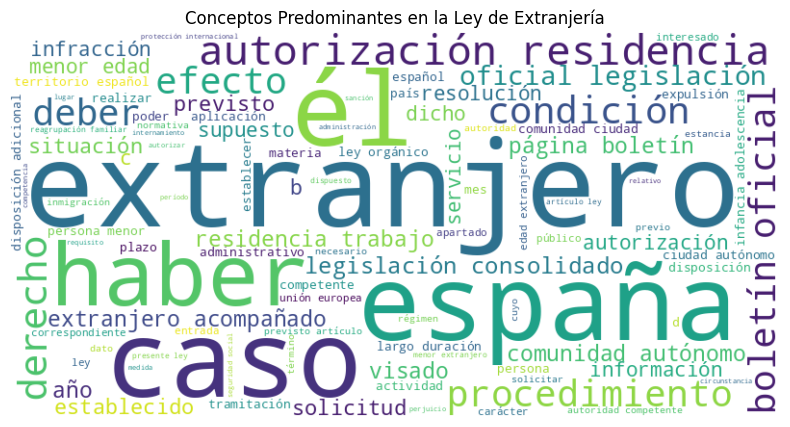

In [10]:
# Juntamos todo el texto limpio en un solo string
todo_el_texto = " ".join(df_ley['Texto_Limpio'])

# Configuramos la nube de palabras
wordcloud = WordCloud(
    width=800, 
    height=400,
    background_color='white',
    colormap='viridis',
    max_words=100
).generate(todo_el_texto)

# Mostrar el gráfico
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Conceptos Predominantes en la Ley de Extranjería")
plt.show()

In [ ]:
# Creamos un ranking de los 10 artículos más extensos y complejos
ranking_df = df_ley.nlargest(10, 'Palabras')[['Referencia', 'Categorias', 'Palabras', 'Riqueza_Lexica']]

# Añadimos una columna de "Prioridad de Asesoría"
# Si el artículo es largo y tiene categorías críticas, le asignamos prioridad Alta
def asignar_prioridad(row):
    if row['Palabras'] > 500 or "Sanciones" in row['Categorias']:
        return "Alta (Requiere Simplificación)"
    return "Media"

ranking_df['Prioridad_App'] = ranking_df.apply(asignar_prioridad, axis=1)

print(ranking_df)

       Referencia                                        Categorias  Palabras  \
181  Artículo 72.  Trabajo, Residencia, Familia, Sanciones, Arraigo      3661   
90   Artículo 72.                                  Trabajo, Arraigo      1477   
159  Artículo 57.  Trabajo, Residencia, Familia, Sanciones, Arraigo      1251   
131  Artículo 35.                         Trabajo, Familia, Arraigo      1007   
134   Artículo 35                                           General       829   
183  Artículo 318                    Residencia, Sanciones, Arraigo       810   
175  Artículo 66.                               Residencia, Arraigo       731   
109  Artículo 17.                               Residencia, Familia       730   
157  Artículo 55.                                         Sanciones       714   
162   Artículo 59                    Residencia, Familia, Sanciones       690   

     Riqueza_Lexica                   Prioridad_App  
181        0.369240  Alta (Requiere Simplificación)  


: 

In [ ]:
# 1. Cargamos un modelo potente en español
# 'paraphrase-multilingual-MiniLM-L12-v2' es ligero y excelente para español
# 


model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

# 2. Convertimos todos los artículos en vectores (esto puede tardar unos segundos)
print("Generando vectores de la ley...")

def limpiar_basura_pdf(texto):
    # Elimina filas de puntos suspensivos (comunes en índices de PDF)
    texto = re.sub(r'\.{2,}', '', texto)
    # Elimina números de página sueltos al final de la línea
    texto = re.sub(r'\s+\d+$', '', texto)
    return texto.strip()

df_ley['Texto_Limpio'] = df_ley['Texto_Legal'].apply(limpiar_basura_pdf)

embeddings_ley = model.encode(df_ley['Texto_Limpio'].tolist(), show_progress_bar=True)


# 3. Guardamos los embeddings en el DataFrame (como una lista de vectores)
# Aseguramos que los vectores son listas estándar
df_ley['Vector'] = df_ley['Vector'].apply(lambda x: x.tolist() if hasattr(x, 'tolist') else x)

# Guardamos en formato JSON
df_ley.to_json("ley_procesada.json", orient="records", force_ascii=False)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generando vectores de la ley...


Batches:   0%|          | 0/6 [00:00<?, ?it/s]

In [ ]:
def buscar_asesoria(pregunta_usuario, df, top_n=3):
    # Convertimos la pregunta del usuario en un vector
    vector_pregunta = model.encode([pregunta_usuario])
    
    # Calculamos la similitud entre la pregunta y todos los artículos
    similitudes = cosine_similarity(vector_pregunta, np.stack(df['Vector'].values))
    
    # Añadimos la puntuación al DataFrame de forma temporal para ordenar
    df['Similitud'] = similitudes[0]
    
    # Devolvemos los N resultados más parecidos en un DataFrame de métricas
    resultado = df.nlargest(top_n, 'Similitud')[['Referencia', 'Categorias', 'Texto_Legal', 'Similitud']]
    return resultado

# --- PRUEBA DE FUEGO ---
# Supongamos que el migrante no sabe términos legales y pregunta:
pregunta = "Como saco papeles para trabajar?"
df_resultados = buscar_asesoria(pregunta, df_ley)

print(df_resultados)

      Referencia Categorias  \
5    Artículo 4.    General   
45  Artículo 36.    General   
46  Artículo 37.    Trabajo   

                                          Texto_Legal  Similitud  
5   Derecho a la documentación.. . . . . . . . . ....   0.452450  
45  Autorización de residencia y trabajo. . . . . ...   0.371934  
46  Autorización de residencia y trabajo por cuent...   0.371934  


: 